# EDA — RAGTruth Dataset

Initial exploration of the RAGTruth dataset: loading `source_info.jsonl` and `response.jsonl`, normalizing context by `task_type`, and merging both DataFrames.

In [1]:
import json
from pathlib import Path

import pandas as pd

DATASET_DIR = Path("../data/raw/ragtruth/dataset")

## 1. Load the DataFrames

In [2]:
source_info_df = pd.read_json(DATASET_DIR / "source_info.jsonl", lines=True)
response_df = pd.read_json(DATASET_DIR / "response.jsonl", lines=True)

print("source_info_df shape:", source_info_df.shape)
print("response_df shape:", response_df.shape)

source_info_df shape: (2965, 5)
response_df shape: (17790, 8)


## 2. Context normalization

The `source_info` field has a different shape depending on `task_type`:
- **Summary**: already a plain text string.
- **QA**: a dict with `question` and `passages`.
- **Data2txt**: a dict of structured data (nested JSON).

In [3]:
def normalize_context(row):
    task_type = row["task_type"]
    source_info = row["source_info"]

    if task_type == "Summary":
        return source_info
    elif task_type == "QA":
        return f"Question: {source_info['question']}\n\nPassages: {source_info['passages']}"
    elif task_type == "Data2txt":
        return json.dumps(source_info, indent=2, ensure_ascii=False)
    else:
        raise ValueError(f"Unknown task_type: {task_type}")


source_info_df["context"] = source_info_df.apply(normalize_context, axis=1)
source_info_df[["source_id", "task_type", "context"]].head()

,source_id,task_type,context
0,15592,Summary,"Seventy years ago, Anne Frank died of typhus i..."
1,15593,Summary,"Andrew Getty, one of the heirs to billions of ..."
2,15594,Summary,"Since Iran's Islamic Revolution in 1979, women..."
3,15595,Summary,"It's the kind of thing you see in movies, like..."
4,15596,Summary,The FBI charged a Philadelphia woman on Thursd...


## 3. Merge response with source_info

In [4]:
response_shape_before = response_df.shape

merged_df = response_df.merge(source_info_df, on="source_id", how="left")

print("response_df shape before merge:", response_shape_before)
print("merged_df shape after merge:", merged_df.shape)
print("\nColumns in merged_df:")
print(list(merged_df.columns))
print("\nvalue_counts of task_type:")
print(merged_df["task_type"].value_counts())

assert merged_df.shape[0] == response_shape_before[0], "The merge dropped or duplicated rows!"

response_df shape before merge: (17790, 8)
merged_df shape after merge: (17790, 13)

Columns in merged_df:
['id', 'source_id', 'model', 'temperature', 'labels', 'split', 'quality', 'response', 'task_type', 'source', 'source_info', 'prompt', 'context']

value_counts of task_type:
task_type
Data2txt    6198
QA          5934
Summary     5658
Name: count, dtype: int64


## 4. Full example for each task_type

In [5]:
for task_type in ["Summary", "QA", "Data2txt"]:
    example = merged_df[merged_df["task_type"] == task_type].iloc[0]

    print("=" * 100)
    print(f"TASK TYPE: {task_type}")
    print("=" * 100)
    print("\n--- CONTEXT ---")
    print(example["context"])
    print("\n--- RESPONSE ---")
    print(example["response"])
    print("\n--- LABELS ---")
    print(json.dumps(example["labels"], indent=2, ensure_ascii=False))
    print("\n")

TASK TYPE: Summary

--- CONTEXT ---
Seventy years ago, Anne Frank died of typhus in a Nazi concentration camp at the age of 15. Just two weeks after her supposed death on March 31, 1945, the Bergen-Belsen concentration camp where she had been imprisoned was liberated -- timing that showed how close the Jewish diarist had been to surviving the Holocaust. But new research released by the Anne Frank House shows that Anne and her older sister, Margot Frank, died at least a month earlier than previously thought. Researchers re-examined archives of the Red Cross, the International Training Service and the Bergen-Belsen Memorial, along with testimonies of survivors. They concluded that Anne and Margot probably did not survive to March 1945 -- contradicting the date of death which had previously been determined by Dutch authorities. In 1944, Anne and seven others hiding in the Amsterdam secret annex were arrested and sent to the  Auschwitz-Birkenau concentration camp. Anne Frank's final entry.

TASK TYPE: Data2txt

--- CONTEXT ---
{
  "name": "Apna Indian Kitchen",
  "address": "718 State St",
  "city": "Santa Barbara",
  "state": "CA",
  "categories": "Gluten-Free, Gastropubs, Vegan, Restaurants, Indian",
  "hours": {
    "Tuesday": "16:30-21:0",
    "Wednesday": "16:30-21:0",
    "Thursday": "16:30-21:0",
    "Friday": "16:30-21:0",
    "Saturday": "16:30-21:0",
    "Sunday": "16:30-21:0"
  },
  "attributes": {
    "BusinessParking": null,
    "RestaurantsReservations": true,
    "OutdoorSeating": true,
    "WiFi": "no",
    "RestaurantsTakeOut": true,
    "RestaurantsGoodForGroups": true,
    "Music": null,
    "Ambience": {
      "divey": false,
      "hipster": true,
      "casual": true,
      "touristy": null,
      "trendy": null,
      "intimate": null,
      "romantic": null,
      "classy": true,
      "upscale": null
    }
  },
  "business_stars": 4.5,
  "review_info": [
    {
      "review_stars": 5.0,
      "review_date": "2022-01-16 14:45:22",
      "review_tex

## 5. Hallucination flag and class balance

In [6]:
merged_df["has_hallucination"] = merged_df["labels"].apply(lambda label_list: len(label_list) > 0)

print("Class balance (has_hallucination), normalized:")
print(merged_df["has_hallucination"].value_counts(normalize=True))

Class balance (has_hallucination), normalized:
has_hallucination
False    0.569196
True     0.430804
Name: proportion, dtype: float64


## 6. Responses per task_type

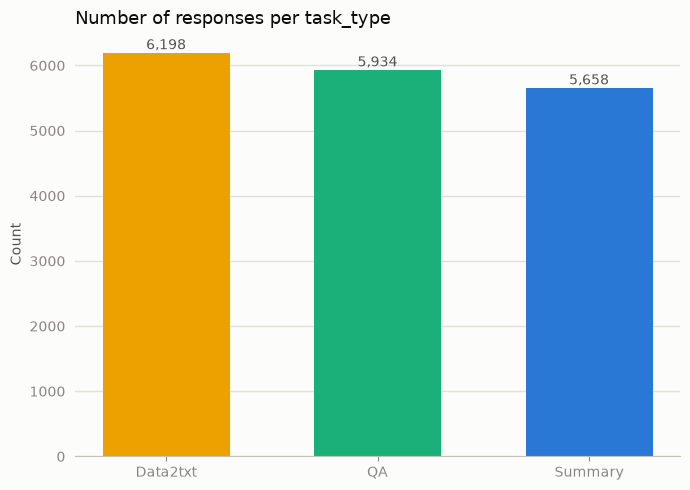

In [7]:
import matplotlib.pyplot as plt

RESULTS_DIR = Path("../results")
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

CHART_SURFACE = "#fcfcfb"
PRIMARY_INK = "#0b0b0b"
SECONDARY_INK = "#52514e"
MUTED_INK = "#898781"
GRIDLINE = "#e1e0d9"
BASELINE = "#c3c2b7"
CRITICAL = "#d03b3b"
SEQUENTIAL_HUE = "#2a78d6"
TASK_TYPE_COLORS = {
    "Summary": "#2a78d6",
    "QA": "#1baf7a",
    "Data2txt": "#eda100",
}

plt.rcParams.update(
    {
        "figure.facecolor": CHART_SURFACE,
        "axes.facecolor": CHART_SURFACE,
        "axes.edgecolor": BASELINE,
        "text.color": PRIMARY_INK,
        "axes.labelcolor": SECONDARY_INK,
        "xtick.color": MUTED_INK,
        "ytick.color": MUTED_INK,
        "font.family": "sans-serif",
    }
)

task_type_counts = merged_df["task_type"].value_counts()
bar_colors = [TASK_TYPE_COLORS[name] for name in task_type_counts.index]

fig, ax = plt.subplots(figsize=(7, 5))
bars = ax.bar(task_type_counts.index, task_type_counts.values, color=bar_colors, width=0.6)
ax.set_title("Number of responses per task_type", color=PRIMARY_INK, fontsize=13, loc="left")
ax.set_ylabel("Count")
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.spines["left"].set_visible(False)
ax.yaxis.grid(True, color=GRIDLINE, linewidth=1)
ax.set_axisbelow(True)
ax.tick_params(left=False)

for bar, value in zip(bars, task_type_counts.values):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height(),
        f"{value:,}",
        ha="center",
        va="bottom",
        color=SECONDARY_INK,
        fontsize=10,
    )

fig.tight_layout()
fig.savefig(RESULTS_DIR / "eda_task_types.png", dpi=150)
plt.show()

## 7. Hallucination rate by model

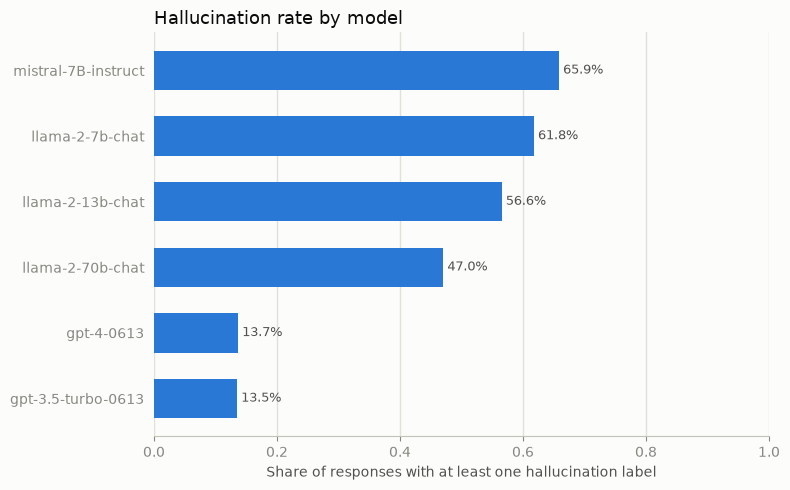

In [8]:
hallucination_by_model = merged_df.groupby("model")["has_hallucination"].mean().sort_values()

fig, ax = plt.subplots(figsize=(8, 5))
bars = ax.barh(hallucination_by_model.index, hallucination_by_model.values, color=SEQUENTIAL_HUE, height=0.6)
ax.set_title("Hallucination rate by model", color=PRIMARY_INK, fontsize=13, loc="left")
ax.set_xlabel("Share of responses with at least one hallucination label")
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.spines["left"].set_visible(False)
ax.xaxis.grid(True, color=GRIDLINE, linewidth=1)
ax.set_axisbelow(True)
ax.tick_params(left=False)
ax.set_xlim(0, 1)

for bar, value in zip(bars, hallucination_by_model.values):
    ax.text(
        bar.get_width(),
        bar.get_y() + bar.get_height() / 2,
        f" {value:.1%}",
        va="center",
        color=SECONDARY_INK,
        fontsize=9,
    )

fig.tight_layout()
fig.savefig(RESULTS_DIR / "eda_hallucination_by_model.png", dpi=150)
plt.show()

## 8. Label type distribution (span-level)

In [9]:
from collections import Counter

label_type_counts = Counter(label["label_type"] for label_list in merged_df["labels"] for label in label_list)

print("Label type counts (span-level):")
for label_type, count in label_type_counts.most_common():
    print(f"  {label_type}: {count}")

Label type counts (span-level):
  Evident Baseless Info: 6237
  Evident Conflict: 5324
  Subtle Baseless Info: 2527
  Subtle Conflict: 201


## 9. Context length in tokens (DeBERTa-v3 tokenizer)

C:\Users\gomez\rag-hallucination-detector\.venv\Lib\site-packages\transformers\convert_slow_tokenizer.py:561: UserWarning: The sentencepiece tokenizer that you are converting to a fast tokenizer uses the byte fallback option which is not implemented in the fast tokenizers. In practice this means that the fast version of the tokenizer can produce unknown tokens whereas the sentencepiece version would have converted these unknown tokens into a sequence of byte tokens matching the original piece of text.
  warnings.warn(


ctx_len describe (global):
count    17790.000000
mean       587.210118
std        326.590734
min        120.000000
25%        352.000000
50%        522.000000
75%        757.000000
max       2189.000000
Name: ctx_len, dtype: float64


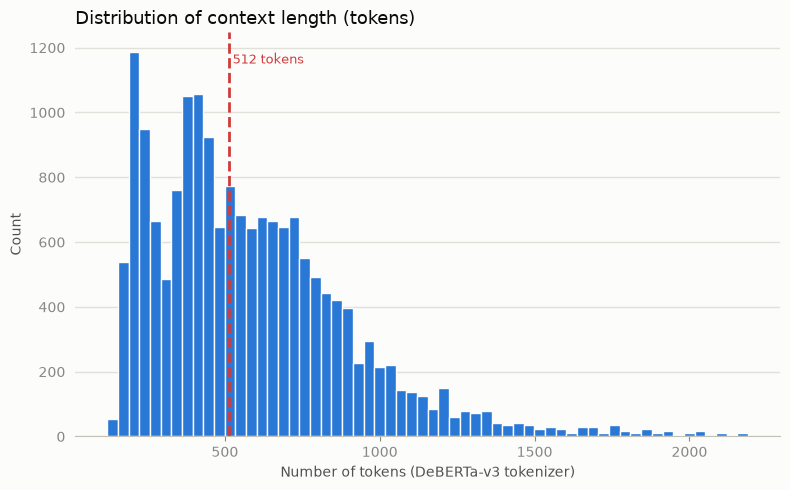

In [10]:
from transformers import AutoTokenizer

tokenizer = AutoTokenizer.from_pretrained("microsoft/deberta-v3-base")

merged_df["ctx_len"] = merged_df["context"].apply(lambda text: len(tokenizer.encode(text, add_special_tokens=True)))

print("ctx_len describe (global):")
print(merged_df["ctx_len"].describe())

fig, ax = plt.subplots(figsize=(8, 5))
ax.hist(merged_df["ctx_len"], bins=60, color=SEQUENTIAL_HUE, edgecolor=CHART_SURFACE)
ax.axvline(512, color=CRITICAL, linewidth=2, linestyle="--")
ax.text(512, ax.get_ylim()[1] * 0.95, " 512 tokens", color=CRITICAL, fontsize=9, va="top")
ax.set_title("Distribution of context length (tokens)", color=PRIMARY_INK, fontsize=13, loc="left")
ax.set_xlabel("Number of tokens (DeBERTa-v3 tokenizer)")
ax.set_ylabel("Count")
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.spines["left"].set_visible(False)
ax.yaxis.grid(True, color=GRIDLINE, linewidth=1)
ax.set_axisbelow(True)
ax.tick_params(left=False)

fig.tight_layout()
fig.savefig(RESULTS_DIR / "eda_context_length.png", dpi=150)
plt.show()

## 10. Context length by task_type

In [11]:
print("ctx_len describe by task_type:")
print(merged_df.groupby("task_type")["ctx_len"].describe())

ctx_len describe by task_type:
            count        mean         std    min    25%    50%    75%     max
task_type                                                                    
Data2txt   6198.0  761.187803  190.917270  355.0  629.0  722.0  847.0  1860.0
QA         5934.0  307.248736  100.049660  120.0  217.0  282.0  395.0   617.0
Summary    5658.0  690.246023  398.727044  148.0  416.0  527.0  890.0  2189.0


## 11. Response length in tokens

response_len describe (global):
count    17790.000000
mean       159.580607
std         69.012517
min          3.000000
25%        111.000000
50%        152.000000
75%        198.000000
max        772.000000
Name: response_len, dtype: float64


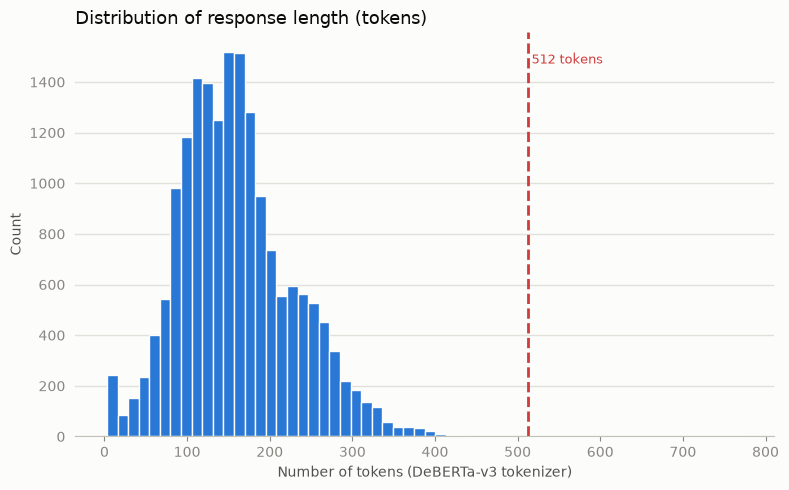

In [12]:
merged_df["response_len"] = merged_df["response"].apply(
    lambda text: len(tokenizer.encode(text, add_special_tokens=True))
)

print("response_len describe (global):")
print(merged_df["response_len"].describe())

fig, ax = plt.subplots(figsize=(8, 5))
ax.hist(merged_df["response_len"], bins=60, color=SEQUENTIAL_HUE, edgecolor=CHART_SURFACE)
ax.axvline(512, color=CRITICAL, linewidth=2, linestyle="--")
ax.text(512, ax.get_ylim()[1] * 0.95, " 512 tokens", color=CRITICAL, fontsize=9, va="top")
ax.set_title("Distribution of response length (tokens)", color=PRIMARY_INK, fontsize=13, loc="left")
ax.set_xlabel("Number of tokens (DeBERTa-v3 tokenizer)")
ax.set_ylabel("Count")
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.spines["left"].set_visible(False)
ax.yaxis.grid(True, color=GRIDLINE, linewidth=1)
ax.set_axisbelow(True)
ax.tick_params(left=False)

fig.tight_layout()
fig.savefig(RESULTS_DIR / "eda_response_length.png", dpi=150)
plt.show()

## 12. Confirm saved figures

In [13]:
for fname in [
    "eda_task_types.png",
    "eda_hallucination_by_model.png",
    "eda_context_length.png",
    "eda_response_length.png",
]:
    path = RESULTS_DIR / fname
    status = "OK" if path.exists() else "MISSING"
    size = path.stat().st_size if path.exists() else 0
    print(f"{fname}: {status} ({size:,} bytes)")

eda_task_types.png: OK (29,412 bytes)
eda_hallucination_by_model.png: OK (47,081 bytes)
eda_context_length.png: OK (37,148 bytes)
eda_response_length.png: OK (40,977 bytes)


## 13. Total sequence length (context + response) and truncation risk

In [14]:
merged_df["total_len"] = (
    merged_df["ctx_len"] + merged_df["response"].apply(lambda text: len(tokenizer(text)["input_ids"])) + 3
)

exceeds_512 = merged_df["total_len"] > 512

print("Rows with total_len > 512 (global):")
print(f"{exceeds_512.mean():.2%}")

print("\nRows with total_len > 512, by task_type:")
print(merged_df.groupby("task_type")["total_len"].apply(lambda s: (s > 512).mean()))

print("\nAmong rows with total_len > 512, share with at least one hallucination span:")
print(f"{merged_df.loc[exceeds_512, 'has_hallucination'].mean():.2%}")

Rows with total_len > 512 (global):
70.34%

Rows with total_len > 512, by task_type:
task_type
Data2txt    0.998871
QA          0.343108
Summary     0.757688
Name: total_len, dtype: float64

Among rows with total_len > 512, share with at least one hallucination span:
50.52%


## 14. Sanity Checks

Four checks on the outputs of `src/data/preprocess.py`: (1) does the group-stratified train/val split preserve class balance, (2) do the raw character-offset spans in `labels` point at the correct substring, (3) how would those spans line up with DeBERTa-v3 token offsets for a future token-classification head, and (4) is the train/val/test split fully leak-free (all three pairwise combinations, not just train/val).

### 14.1 Label balance across splits

Compares `label_response` proportions in the full pre-split dataset against the `train` / `val` / `test` parquet files produced by `src/data/preprocess.py`, to confirm the source_id-group-majority stratification used for the val split didn't skew class balance.

In [15]:
PROCESSED_DIR = Path("../data/processed")

full_label_dist = merged_df["has_hallucination"].astype(int).value_counts(normalize=True).sort_index()

split_dfs = {
    "train": pd.read_parquet(PROCESSED_DIR / "response_level_train.parquet"),
    "val": pd.read_parquet(PROCESSED_DIR / "response_level_val.parquet"),
    "test": pd.read_parquet(PROCESSED_DIR / "response_level_test.parquet"),
}

label_balance = pd.DataFrame({"full (pre-split)": full_label_dist})
for split_name, split_df in split_dfs.items():
    label_balance[split_name] = split_df["label_response"].value_counts(normalize=True).sort_index()

label_balance.index.name = "label_response"
print("Label balance (proportion of rows), full dataset vs. each split:")
label_balance

Label balance (proportion of rows), full dataset vs. each split:


,full (pre-split),train,val,test
label_response,,,,
0,0.569196,0.553837,0.561218,0.650741
1,0.430804,0.446163,0.438782,0.349259


### 14.2 Span re-highlighting (offset sanity check)

5 random hallucinated responses, with each annotated span's raw `start`/`end` character offsets re-inserted into the response text as `>>> ... <<<` markers, so we can visually confirm the offsets point at the intended substring (no shift / off-by-one).

In [16]:
def highlight_spans(text, labels):
    """Wrap each labeled span in the response text with '>>> <<<' markers.

    Assumes non-overlapping spans (true for RAGTruth's span annotations); spans are
    inserted left-to-right using a running cursor.
    """
    spans = sorted(labels, key=lambda label: label["start"])
    pieces = []
    cursor = 0
    for label in spans:
        start, end = label["start"], label["end"]
        pieces.append(text[cursor:start])
        pieces.append(">>> ")
        pieces.append(text[start:end])
        pieces.append(" <<<")
        cursor = end
    pieces.append(text[cursor:])
    return "".join(pieces)


hallucinated_df = merged_df[merged_df["has_hallucination"]]
sample_df = hallucinated_df.sample(n=5, random_state=42)

for _, row in sample_df.iterrows():
    print("=" * 100)
    print(f"source_id={row['source_id']}  task_type={row['task_type']}  num_spans={len(row['labels'])}")
    print("-" * 100)
    for label in row["labels"]:
        start, end = label["start"], label["end"]
        offsets_ok = row["response"][start:end] == label["text"]
        print(f"  span[{start}:{end}] offset check (response[start:end] == labels.text): {offsets_ok}")
    print()
    print(highlight_spans(row["response"], row["labels"]))
    print()

source_id=14973  task_type=Data2txt  num_spans=1
----------------------------------------------------------------------------------------------------
  span[264:286] offset check (response[start:end] == labels.text): True

Pizza My Heart is a popular restaurant located at 6533 Trigo Road in Isla Vista, California. It offers a variety of pizza options including vegetarian and gluten-free pizzas. Customers have praised the quality of the pizza and the friendly service. The restaurant >>> offers outdoor seating <<< and takeout options. Wi-Fi is available and the atmosphere is described as a casual pizza joint with a mix of Latin and pop music. Overall, Pizza My Heart seems to be a great choice for those looking for delicious and affordable pizza in Isla Vista.

source_id=14555  task_type=Data2txt  num_spans=1
----------------------------------------------------------------------------------------------------
  span[529:548] offset check (response[start:end] == labels.text): True

Based on

### 14.3 Token-label alignment preview

For one of the 5 examples above, tokenizes the response with `return_offsets_mapping=True` and shows, for the first 40 tokens, which ones fall inside a labeled span — i.e. which tokens would receive `B-HALL`/`I-HALL` if we built a token-classification representation (representation C) right now.

In [17]:
example_row = sample_df.iloc[0]
response_text = example_row["response"]
spans = [(label["start"], label["end"]) for label in example_row["labels"]]

encoding = tokenizer(response_text, return_offsets_mapping=True, add_special_tokens=True)
tokens = tokenizer.convert_ids_to_tokens(encoding["input_ids"])
offsets = encoding["offset_mapping"]


def is_inside_any_span(token_offset, spans):
    token_start, token_end = token_offset
    if token_start == token_end:
        return False  # special tokens (e.g. [CLS]/[SEP]) have an empty offset
    return any(token_start < span_end and token_end > span_start for span_start, span_end in spans)


print(f"source_id={example_row['source_id']}  task_type={example_row['task_type']}  num_spans={len(spans)}")

token_alignment_df = pd.DataFrame(
    {
        "token": tokens[:40],
        "offset_mapping": offsets[:40],
        "is_inside_some_span": [is_inside_any_span(offset, spans) for offset in offsets[:40]],
    }
)
token_alignment_df

source_id=14973  task_type=Data2txt  num_spans=1


,token,offset_mapping,is_inside_some_span
0,[CLS],"(0, 0)",False
1,▁Pizza,"(0, 5)",False
2,▁My,"(5, 8)",False
3,▁Heart,"(8, 14)",False
4,▁is,"(14, 17)",False
5,▁a,"(17, 19)",False
6,▁popular,"(19, 27)",False
7,▁restaurant,"(27, 38)",False
8,▁located,"(38, 46)",False
9,▁at,"(46, 49)",False


### 14.4 Leakage check, formalized (all three pairwise splits)

`src/data/preprocess.py` already asserts no `source_id` overlap between train and val at save time. Here we re-derive it from the saved parquet files and check all three pairwise combinations: train/val, train/test, val/test.

In [18]:
train_ids = set(split_dfs["train"]["source_id"])
val_ids = set(split_dfs["val"]["source_id"])
test_ids = set(split_dfs["test"]["source_id"])

train_val_overlap = train_ids & val_ids
train_test_overlap = train_ids & test_ids
val_test_overlap = val_ids & test_ids

assert not train_val_overlap, f"Leakage: {len(train_val_overlap)} source_id(s) in both train and val"
assert not train_test_overlap, f"Leakage: {len(train_test_overlap)} source_id(s) in both train and test"
assert not val_test_overlap, f"Leakage: {len(val_test_overlap)} source_id(s) in both val and test"

print(f"train ({len(train_ids)}) vs val ({len(val_ids)}):   {len(train_val_overlap)} shared source_id(s) -- OK")
print(f"train ({len(train_ids)}) vs test ({len(test_ids)}):  {len(train_test_overlap)} shared source_id(s) -- OK")
print(f"val ({len(val_ids)}) vs test ({len(test_ids)}):    {len(val_test_overlap)} shared source_id(s) -- OK")
print("\nAll three pairwise leakage checks passed.")

train (2263) vs val (252):   0 shared source_id(s) -- OK
train (2263) vs test (450):  0 shared source_id(s) -- OK
val (252) vs test (450):    0 shared source_id(s) -- OK

All three pairwise leakage checks passed.
